# Test — Cell Lattice + PINNs


In [1]:
import numpy as np
from dyn_modelling.models.cell_lattice import build_lattice, simulate_cell_lattice, compute_distance_matrix, compute_weights, compute_rhs, external_signal
from dyn_modelling.methods.pinn import ANN, init_params, make_pinn, train
from dyn_modelling.utils.plots import plot_graph, plot_trajectories, plot_loss, plot_parameter_evolution, plot_predictions
from dyn_modelling.utils.data import add_noise
import jax
import jax.numpy as jnp

## 1. Build the lattice


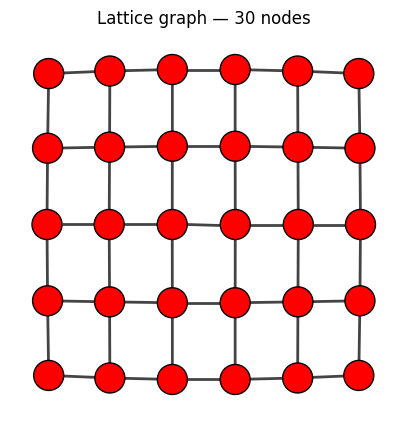

In [2]:
rows, cols = 5, 6
N = rows * cols

g = build_lattice(rows, cols)
plot_graph(g)

## 2. Simulate cell lattice


In [3]:
# Parameters
a_params = np.array([2.4, 3.5, 2.0, 1.0])
l_params = np.array([1.0, 1.0, 0.2])
t_on, t_off = 80.0, 500.0
t_end, n_steps = 500.0, 100
neigh_order = 2

# Build RHS
dist_matrix = compute_distance_matrix(g)
rhs = compute_rhs(g, dist_matrix, l_params, neigh_order, t_on, t_off, a_params=a_params)


# Initial conditions
np.random.seed(1)
x0 = np.random.rand(N * 3)
t_eval = np.linspace(0, t_end, n_steps)

# Simulate
y = simulate_cell_lattice(rhs, x0, (0, t_end), t_eval)

## 3. Plot trajectories — clean data


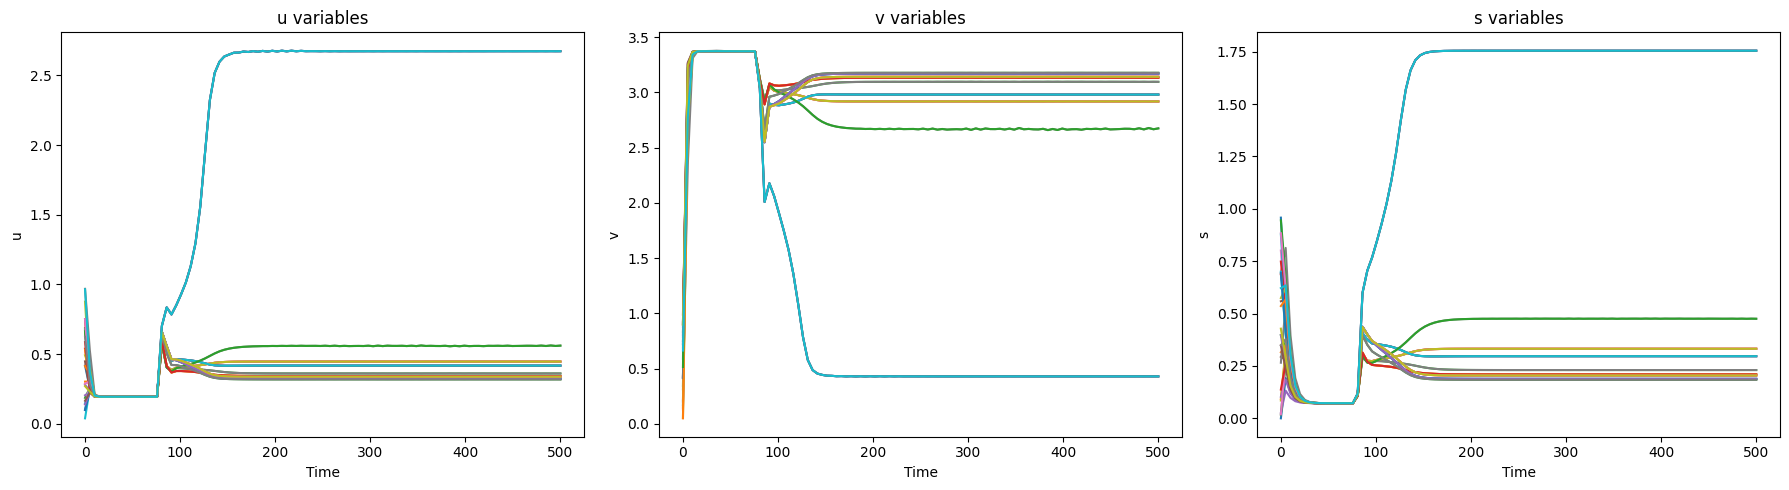

In [4]:
plot_trajectories(t_eval, y)

## 4. Plot trajectories — noisy data


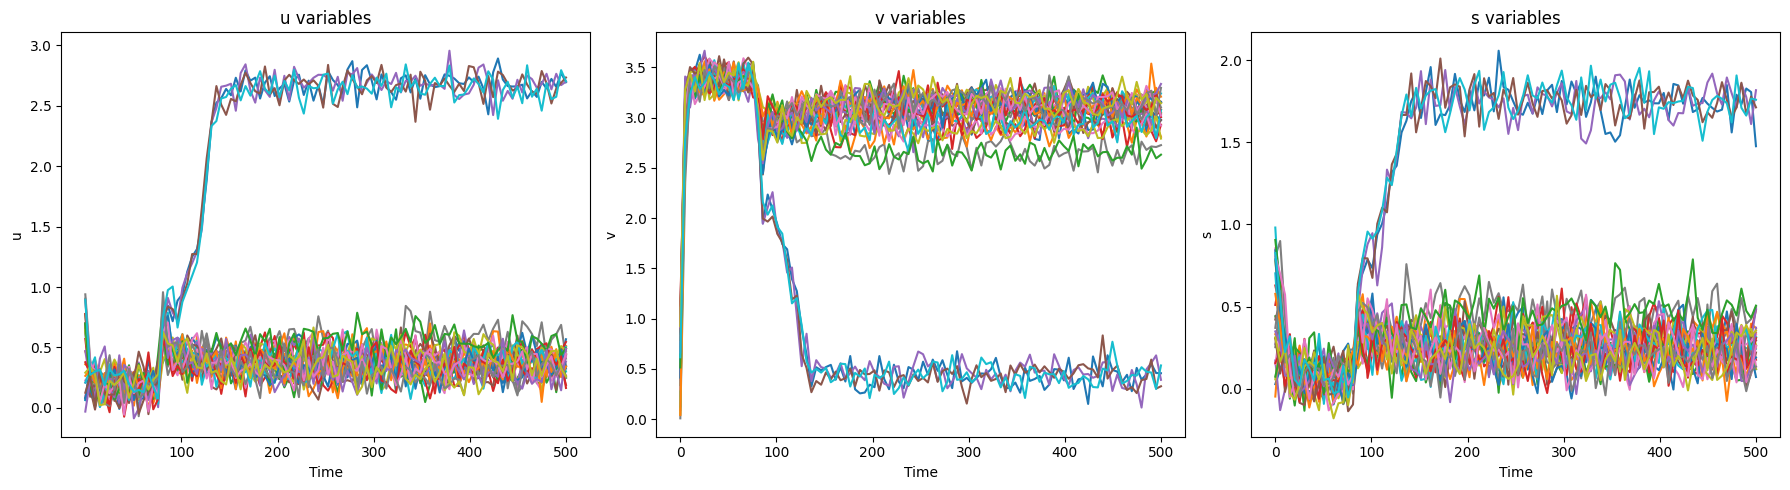

In [5]:
y_noisy = add_noise(y, noise_level=0.1)
plot_trajectories(t_eval, y_noisy)

## 5. Prepare data for PINN


In [6]:
# PINN expects T shape (n_steps, 1) and Y shape (n_steps, 3*N)
T = t_eval[:, None]       # (100, 1)
Y = y.T                   # (100, 3*N) clean
#Y_noisy = y_noisy.T       # (100, 3*N) noisy

## 6. Train PINN


In [7]:
# Build PINN
rhs = compute_rhs(g, dist_matrix, l_params, neigh_order, t_on, t_off)
batch_loss, grad_fn = make_pinn(rhs)

# Initialize ANN and model parameters
topology = [1, 64, 64, 64, 64, 3 * N]
ann_params = init_params(topology)
a_init = np.ones(4)
a_true = a_params.copy()

# Train
ann_params, a_list, loss_history = train(
    ann_params, a_init, T, Y,
    batch_loss, grad_fn,
    lmbd=0.2, n_epochs=50000,
    lr_ann=1e-4, lr_model=1e-2, momentum=0.9
)

[     0] loss = 69.929398 | a = [0.17116803 0.51294506 0.9999935  0.27197552]
[  5000] loss = 1.138541 | a = [2.9160197 3.4439044 1.838823  0.3746383]
[ 10000] loss = 0.324753 | a = [2.3469892 3.4715037 2.0193884 0.8787947]
[ 15000] loss = 0.219327 | a = [2.5177968 3.4800668 2.0038989 0.7629003]
[ 20000] loss = 0.173348 | a = [2.4973273 3.4838452 2.0023944 0.8017331]
[ 25000] loss = 0.143044 | a = [2.472719  3.4864285 2.0032723 0.8394087]
[ 30000] loss = 0.121494 | a = [2.4633844  3.488076   2.0038004  0.85826457]
[ 35000] loss = 0.105524 | a = [2.4671774  3.489078   2.0038264  0.86204016]
[ 40000] loss = 0.093233 | a = [2.4802983 3.489561  2.0031307 0.8553678]
[ 45000] loss = 0.083726 | a = [2.49689   3.4897308 2.0020528 0.8445483]


## 7. Plot loss


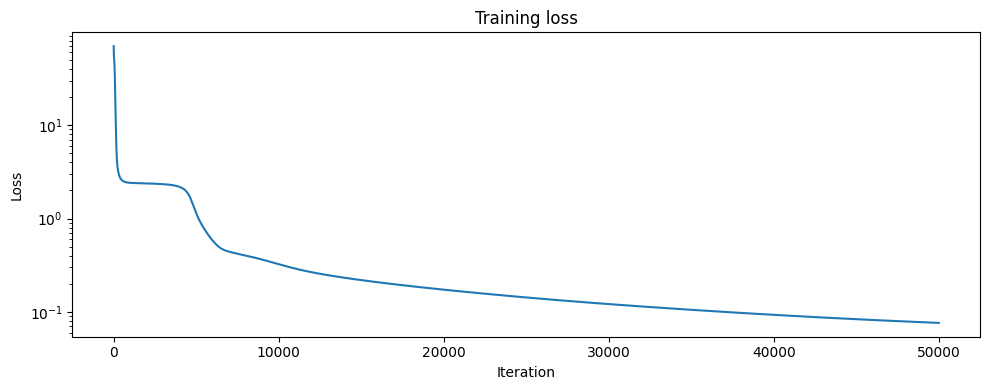

In [8]:
plot_loss(loss_history)

## 8. Plot parameter evolution


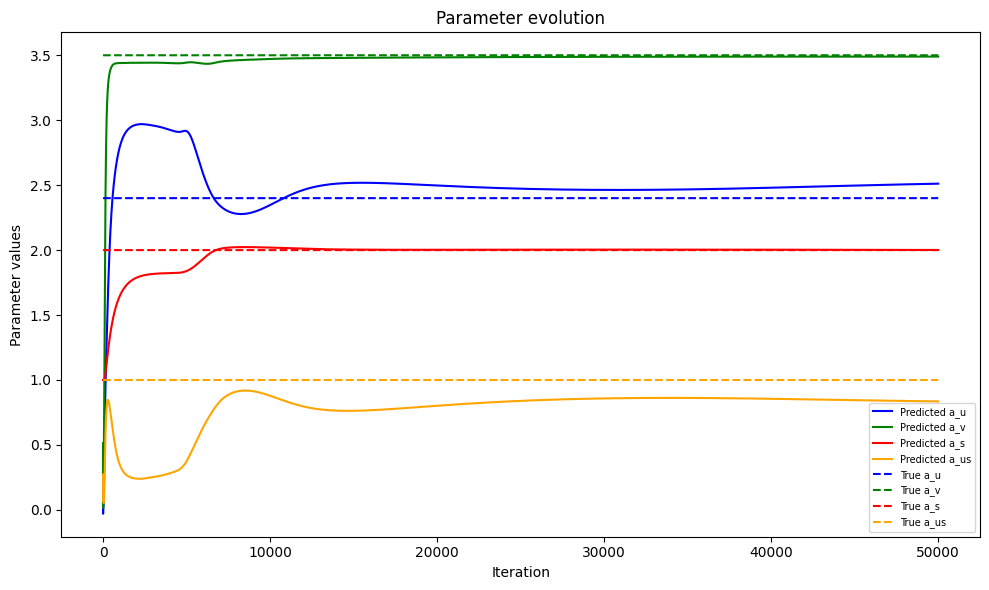

In [9]:
plot_parameter_evolution(a_list, a_true)

## 9. Plot predicted vs true trajectories


D:\Projects\dyn-modelling\src\dyn_modelling\utils\plots.py:141: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


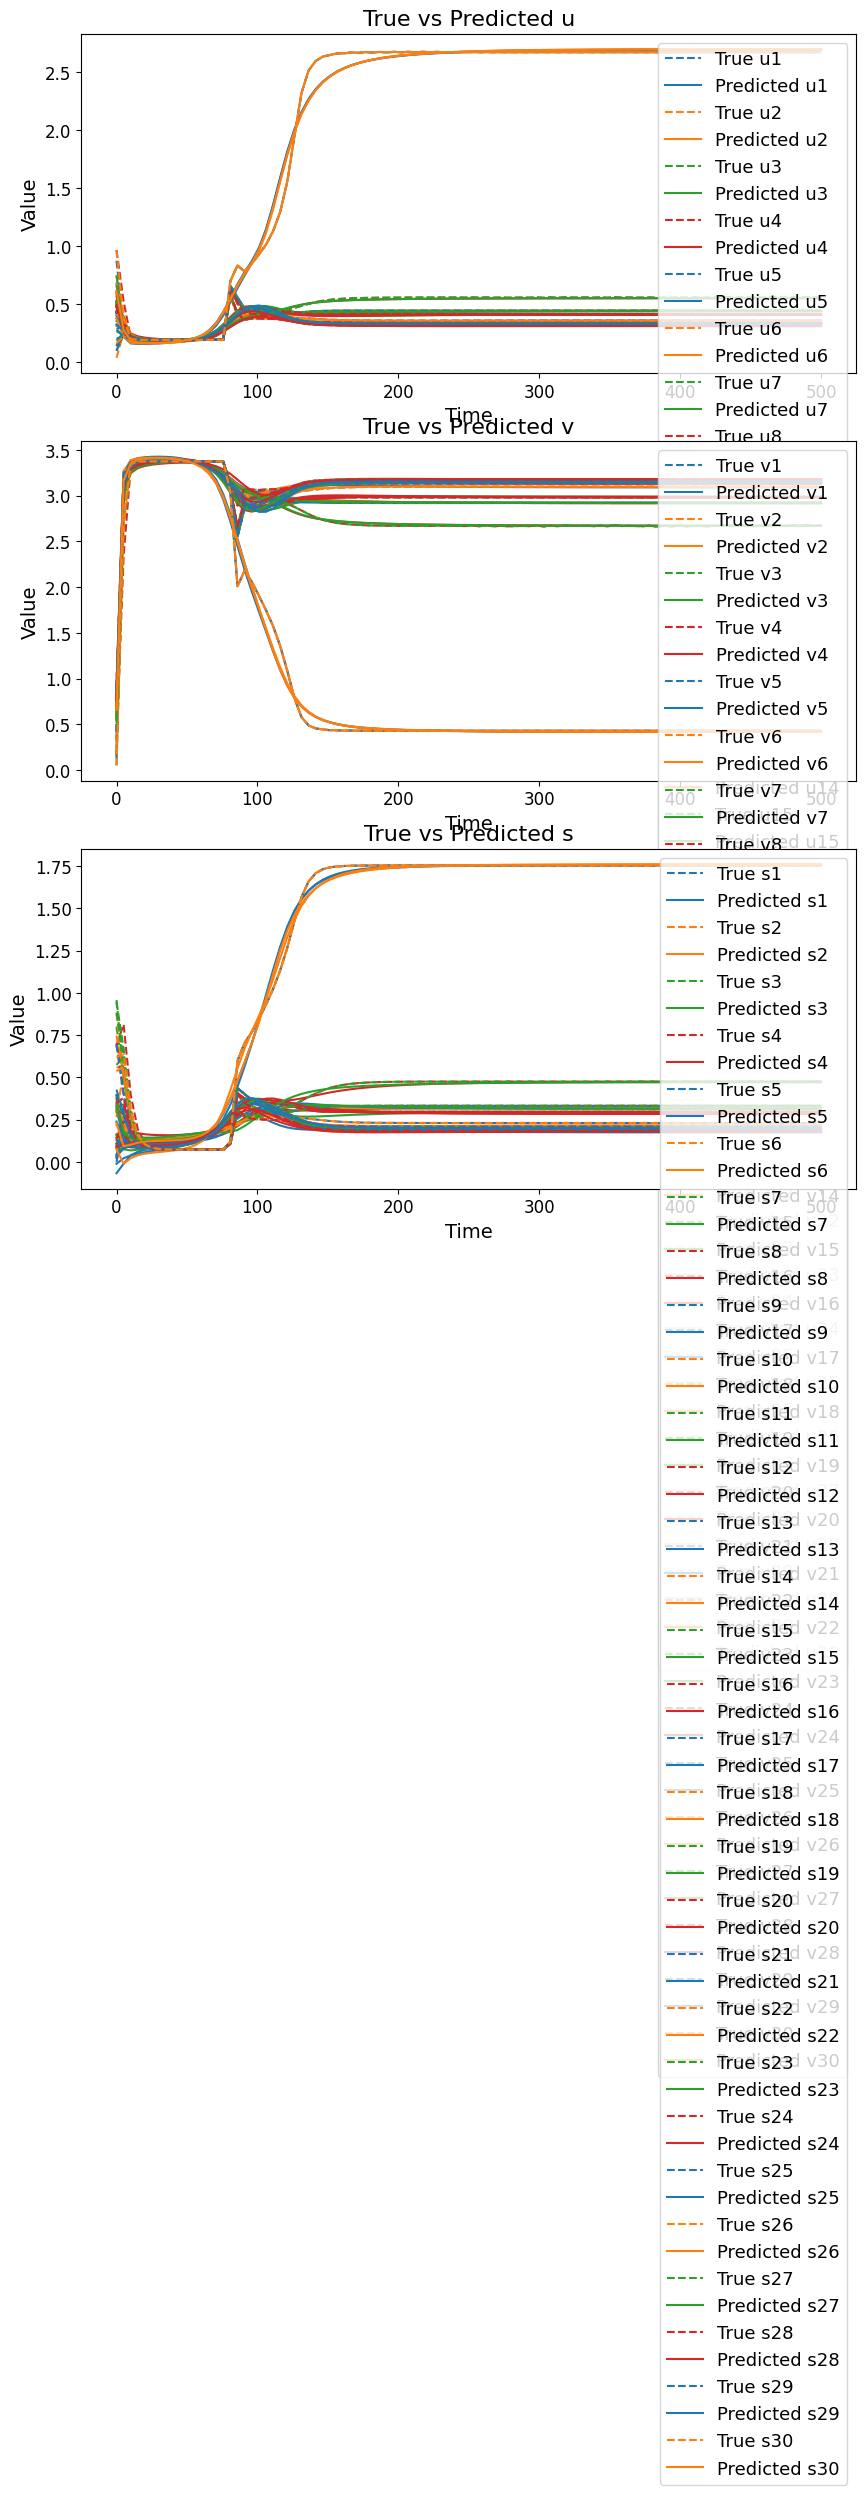

In [10]:
batch_ANN = jax.vmap(lambda t: ANN(ann_params, t))
y_pred = np.array(batch_ANN(T))   # (n_steps, 3*N)

plot_predictions(t_eval, y_pred, Y)

## 10. Final identified parameters


In [11]:
a_final = a_list[-1]
print(f'True parameters:      {a_true}')
print(f'Identified parameters: {a_final}')
print(f'Absolute error:        {np.abs(a_final - a_true)}')

True parameters:      [2.4 3.5 2.  1. ]
Identified parameters: [2.5114021  3.4897878  2.0009844  0.83513814]
Absolute error:        [0.11140203 0.01021218 0.00098443 0.16486186]
